# Chest X-ray Pneumonia Detection

**Notebook:** 01 — Data Exploration  

**Objective:**  
Explore the chest X-ray dataset to understand its structure, class distribution, and visual characteristics before building a classification model.

In [1]:
# Core libraries for data exploration
import os
from pathlib import Path

# Visualization and image handling
import matplotlib.pyplot as plt
from PIL import Image

# Numerical operation
import numpy as np

In [2]:
# Define project root and data directories
PROJECT_ROOT = Path("..") # notebooks/ -> project root
DATA_DIR = PROJECT_ROOT / "data" / "raw"

TRAIN_DIR = DATA_DIR / "train"
VAL_DIR   = DATA_DIR / "val"
TEST_DIR  = DATA_DIR / "test"

TRAIN_DIR, VAL_DIR, TEST_DIR

(WindowsPath('../data/raw/train'),
 WindowsPath('../data/raw/val'),
 WindowsPath('../data/raw/test'))

In [3]:
# Sanity check
print("Train exists:", TRAIN_DIR.exists())
print("Val exists  :", VAL_DIR.exists())
print("Test exists :", TEST_DIR.exists())

Train exists: True
Val exists  : True
Test exists : True


In [4]:
# Inspect class folders inside training directory
classes = sorted(os.listdir(TRAIN_DIR))
classes

['NORMAL', 'PNEUMONIA']

In [5]:
# Count number of images per class in each split
def count_images(split_dir):
    return {
        cls: len(list((split_dir / cls).glob("*")))
        for cls in os.listdir(split_dir)
    }

print("Train:", count_images(TRAIN_DIR))
print("Val  :", count_images(VAL_DIR))
print("Test :", count_images(TEST_DIR))

Train: {'NORMAL': 1341, 'PNEUMONIA': 3875}
Val  : {'NORMAL': 8, 'PNEUMONIA': 8}
Test : {'NORMAL': 234, 'PNEUMONIA': 390}


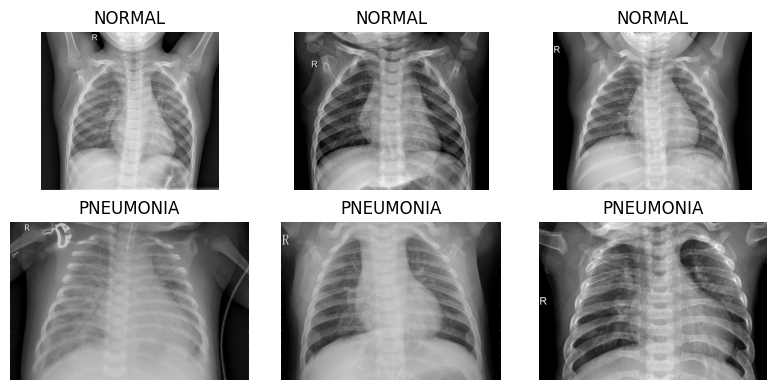

In [6]:
# Visualize sample X-ray images from each class
def show_samples(split_dir, n=3):
    plt.figure(figsize=(8, 4))
    idx = 1

    for cls in os.listdir(split_dir):
        images = list((split_dir / cls).glob("*"))[:n]

        for img_path in images:
            img = Image.open(img_path).convert("L")
            plt.subplot(2, n, idx)
            plt.imshow(img, cmap="gray")
            plt.title(cls)
            plt.axis("off")
            idx += 1

    plt.tight_layout()
    plt.show()

show_samples(TRAIN_DIR, n=3)

### Key Observations from Data Exploration

- Chest X-ray images are grayscale and not uniform in size or contrast.
- The dataset is clearly imbalanced, with many more PNEUMONIA images than NORMAL images.
- Class labels depend entirely on folder structure, so keeping directories clean is critical.
- Visual inspection shows noise and artifacts in some images, so preprocessing must be done carefully.
- Because of class imbalance, accuracy alone is not reliable; recall and confusion matrix will matter more.

### Conclusions

- The problem is a binary classification task: NORMAL vs PNEUMONIA.
- Images will need resizing, normalization, and consistent grayscale handling before training.
- Class imbalance must be handled during both training and evaluation.
- A simple CNN baseline will be trained first, and improvements can be added later if needed.